In [1]:
import os
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import entropy

# Define the candidate path once as it doesn't change
candidate_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/dev_candidate_embeddings.pkl'

def load_embeddings(user_path, candidate_path):
    with open(user_path, 'rb') as f:
        user_embeddings = pickle.load(f)
    
    with open(candidate_path, 'rb') as f:
        candidate_embeddings_dict = pickle.load(f)
    
    candidate_ids, candidate_embeddings = zip(*candidate_embeddings_dict.items())
    candidate_embeddings = torch.tensor(np.array(candidate_embeddings))
    
    return user_embeddings, candidate_embeddings

def calculate_mean_embedding(embeddings):
    embeddings_tensor = torch.tensor(embeddings)  # Convert to tensor if it's not already
    return torch.mean(embeddings_tensor, dim=0)

def calculate_angles(embeddings, mean_embedding):
    embeddings_tensor = torch.tensor(embeddings)  # Ensure embeddings are tensors
    dot_product = torch.sum(embeddings_tensor * mean_embedding, dim=-1)
    norm_embeddings = torch.norm(embeddings_tensor, dim=-1)
    norm_mean_embedding = torch.norm(mean_embedding)
    cos_theta = dot_product / (norm_embeddings * norm_mean_embedding)
    angles = torch.acos(torch.clamp(cos_theta, -1.0, 1.0))
    return angles

def remove_nan_and_inf(data):
    return data[np.isfinite(data)]

def calculate_kde(angles, norms):
    # Flatten and remove NaN values
    valid_angles = remove_nan_and_inf(angles.flatten())
    valid_norms = remove_nan_and_inf(norms.flatten())
    
    # Ensure that both arrays have the same length
    min_length = min(len(valid_angles), len(valid_norms))
    valid_angles = valid_angles[:min_length]
    valid_norms = valid_norms[:min_length]

    # Stack the valid data
    valid_data = np.vstack([valid_angles, valid_norms])
    
    # Remove zero/invalid entries (if any left after clipping)
    valid_data = valid_data[:, np.all(valid_data > 0, axis=0)]
    
    kde = gaussian_kde(valid_data)
    
    # Create a grid for KDE plot
    angle_range = np.linspace(0, np.pi, 100)
    norm_range = np.linspace(0, 10, 100)  # Adjusted to a standard scale (0 to 10)
    angle_grid, norm_grid = np.meshgrid(angle_range, norm_range)
    grid_positions = np.vstack([angle_grid.ravel(), norm_grid.ravel()])
    
    # Get the density on the grid
    density = kde(grid_positions).reshape(angle_grid.shape)
    
    return angle_grid, norm_grid, density

def adjust_embedding_dimensions(user_embeddings, candidate_embeddings):
    # Assuming the last dimension (D) is already matching
    user_interest_dim = user_embeddings.shape[1]  # num_interest for users
    candidate_interest_dim = candidate_embeddings.shape[1]  # num_interest for candidates

    if user_interest_dim != candidate_interest_dim:
        if candidate_interest_dim < user_interest_dim:
            # Pad candidate embeddings with zeros to match the user's interest dimension
            padding = user_interest_dim - candidate_interest_dim
            candidate_embeddings = torch.nn.functional.pad(candidate_embeddings, (0, 0, 0, padding), "constant", 0)
        else:
            # Truncate candidate embeddings to match user embeddings' interest dimension
            candidate_embeddings = candidate_embeddings[:, :user_interest_dim, :]
    
    return candidate_embeddings

def calculate_shannon_entropy(data, bins=100):
    """Calculate Shannon Entropy for a given dataset."""
    data = remove_nan_and_inf(data)
    if data.size == 0:
        return 0.0  # Return zero entropy if data is empty
    
    histogram, _ = np.histogram(data, bins=bins, density=True)
    entropy_value = entropy(histogram + np.finfo(float).eps)  # Add eps for numerical stability
    return entropy_value

def plot_geometry(user_angles, user_norms, news_angles, news_norms, max_norm=10.0):
    plt.figure(figsize=(8, 6))
    
    # Set up the plot with a semicircular (180-degree) range
    ax = plt.subplot(111, projection='polar')
    
    # Convert angles to radians for plotting
    user_angles_rad = np.clip(user_angles.flatten(), 0, np.pi)
    news_angles_rad = np.clip(news_angles.flatten(), 0, np.pi)
    
    # Plot the KDE for users
    user_angle_grid, user_norm_grid, user_density = calculate_kde(user_angles_rad, user_norms)
    ax.contourf(user_angle_grid, user_norm_grid, user_density, levels=200, cmap="Oranges", alpha=0.5)
    
    # Plot the KDE for news
    news_angle_grid, news_norm_grid, news_density = calculate_kde(news_angles_rad, news_norms)
    ax.contourf(news_angle_grid, news_norm_grid, news_density, levels=200, cmap="Blues", alpha=0.5)
    
    # Overlay scatter plots for better visibility
    ax.scatter(user_angles_rad, user_norms, color='red', s=1, alpha=0.7, label='User Points')
    ax.scatter(news_angles_rad, news_norms, color='blue', s=1, alpha=0.7, label='News Points')
    
    # Set the radial ticks (embedding length) to increments and avoid overlapping
    ax.set_rgrids([2, 4, 6, 8, 10], labels=['2', '4', '6', '8', '10'], angle=180.0)
    
    # Set custom angular ticks (angle relative to mean user) starting from 0° to 180° counterclockwise
    ax.set_thetagrids([0, 20, 40, 60, 80, 100, 120, 140, 160, 180], labels=['0°', '20°', '40°', '60°', '80°', '100°', '120°', '140°', '160°', '180°'])
    
    # Update radial limits to accommodate larger embedding lengths
    ax.set_ylim(0, max_norm)
    ax.set_xlim(0, np.pi)
    
    ax.set_xlabel('Embedding length', labelpad=20)
    ax.set_ylabel('Angle relative to mean user', labelpad=20)
    ax.legend(loc='upper right')
    
    plt.show()

def process_embeddings_geometry(N, user_path, candidate_path):
    print(f'Processing Geometry for N={N}')
    user_embeddings, candidate_embeddings = load_embeddings(user_path, candidate_path)
    candidate_embeddings = adjust_embedding_dimensions(user_embeddings, candidate_embeddings)
    
    # Geometry visualization
    mean_user_embedding = calculate_mean_embedding(user_embeddings)
    user_angles = calculate_angles(user_embeddings, mean_user_embedding)
    user_norms = torch.norm(torch.tensor(user_embeddings), dim=-1)
    
    news_angles = calculate_angles(candidate_embeddings, mean_user_embedding)
    news_norms = torch.norm(candidate_embeddings, dim=-1)
    
    # Calculate Shannon Entropy for the distributions
    user_angle_entropy = calculate_shannon_entropy(user_angles)
    user_norm_entropy = calculate_shannon_entropy(user_norms)
    news_angle_entropy = calculate_shannon_entropy(news_angles)
    news_norm_entropy = calculate_shannon_entropy(news_norms)
    
    print(f'Shannon Entropy for User Angles: {user_angle_entropy}')
    print(f'Shannon Entropy for User Norms: {user_norm_entropy}')
    print(f'Shannon Entropy for News Angles: {news_angle_entropy}')
    print(f'Shannon Entropy for News Norms: {news_norm_entropy}')
    
    # Determine the max norm to adjust the plot's radial range dynamically
    max_norm = max(user_norms.max().item(), news_norms.max().item())
    
    # Plot the geometry with the dynamically adjusted radial range
    plot_geometry(user_angles, user_norms, news_angles, news_norms, max_norm=max_norm)

Processing Geometry for N=5


/tmp/ipykernel_2122908/753296422.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings_tensor = torch.tensor(embeddings)  # Ensure embeddings are tensors
/tmp/ipykernel_2122908/753296422.py:38: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  return data[np.isfinite(data)]


Shannon Entropy for User Angles: 2.3470629900382116
Shannon Entropy for User Norms: 3.0851430043267487
Shannon Entropy for News Angles: 3.8649096319663396
Shannon Entropy for News Norms: 1.2359950660218035


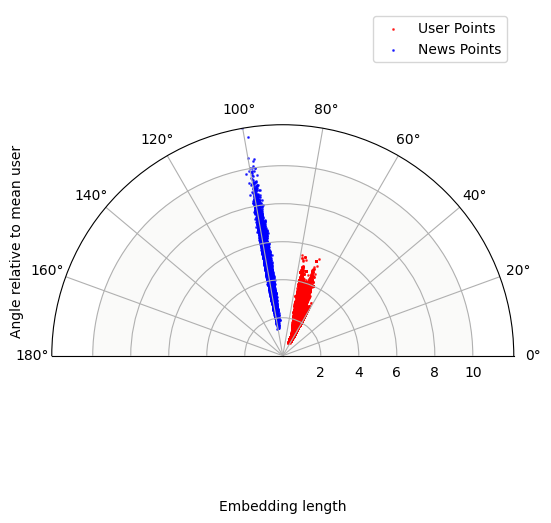

In [2]:
#N =5 without disentanglement 
process_embeddings_geometry(
    N=5,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=5


/tmp/ipykernel_2122908/753296422.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings_tensor = torch.tensor(embeddings)  # Ensure embeddings are tensors
/tmp/ipykernel_2122908/753296422.py:38: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  return data[np.isfinite(data)]


Shannon Entropy for User Angles: 1.5591444782401775
Shannon Entropy for User Norms: 3.4746778402638183
Shannon Entropy for News Angles: 3.8842061368114047
Shannon Entropy for News Norms: 1.2359950660218035


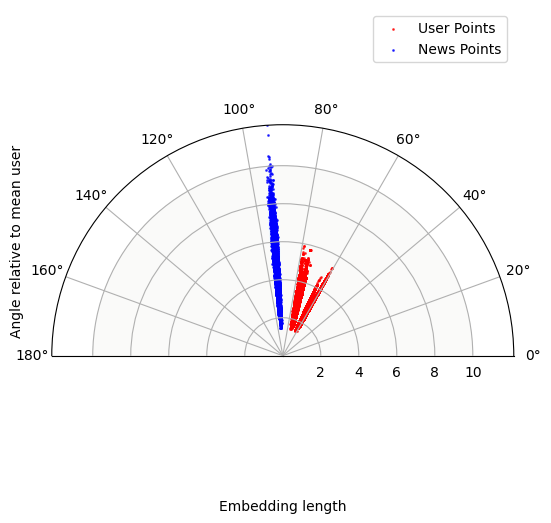

In [3]:
#N =5 with disentanglement
process_embeddings_geometry(
    N=5,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=10


/tmp/ipykernel_2122908/753296422.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings_tensor = torch.tensor(embeddings)  # Ensure embeddings are tensors
/tmp/ipykernel_2122908/753296422.py:38: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  return data[np.isfinite(data)]


Shannon Entropy for User Angles: 2.6587325500081835
Shannon Entropy for User Norms: 2.5059462021286514
Shannon Entropy for News Angles: 3.565665823494423
Shannon Entropy for News Norms: 0.6928792984639451


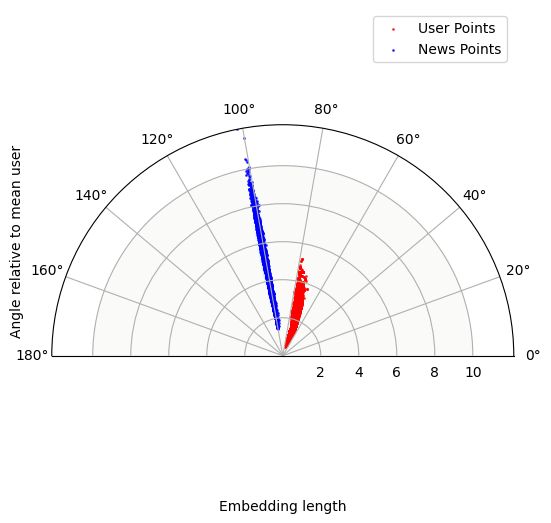

In [4]:
#N =10 without disentanglement
process_embeddings_geometry(
    N=10,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=10


/tmp/ipykernel_2122908/753296422.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings_tensor = torch.tensor(embeddings)  # Ensure embeddings are tensors
/tmp/ipykernel_2122908/753296422.py:38: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  return data[np.isfinite(data)]


Shannon Entropy for User Angles: 2.225007051589906
Shannon Entropy for User Norms: 2.5302875333072463
Shannon Entropy for News Angles: 3.4580617376279004
Shannon Entropy for News Norms: 0.6928792984639451


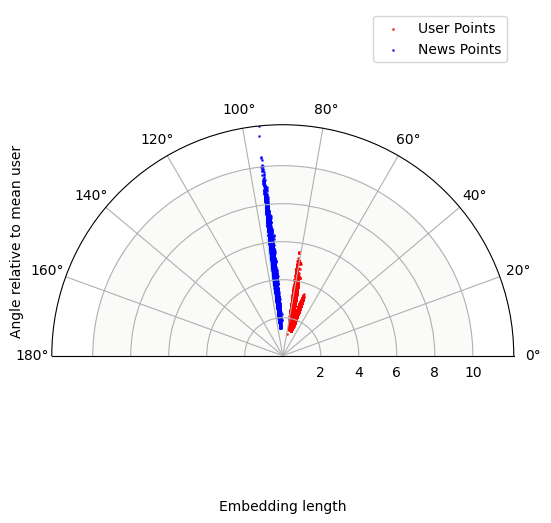

In [5]:
#N =10 with disentanglement
process_embeddings_geometry(
    N=10,
    user_path= '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=25


/tmp/ipykernel_2122908/753296422.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings_tensor = torch.tensor(embeddings)  # Ensure embeddings are tensors
/tmp/ipykernel_2122908/753296422.py:38: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  return data[np.isfinite(data)]


Shannon Entropy for User Angles: 2.6727340165085773
Shannon Entropy for User Norms: 1.9482801172572528
Shannon Entropy for News Angles: 3.7066597219823763
Shannon Entropy for News Norms: 0.3150626793671592


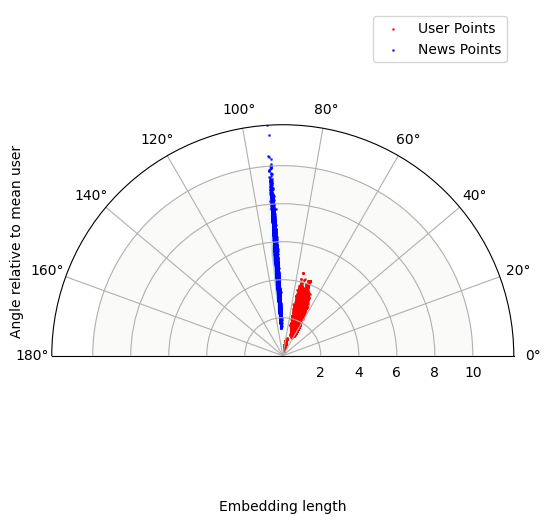

In [6]:
#N = 25 without disentanglement
process_embeddings_geometry(
    N=25,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)


Processing Geometry for N=25


/tmp/ipykernel_2122908/753296422.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings_tensor = torch.tensor(embeddings)  # Ensure embeddings are tensors
/tmp/ipykernel_2122908/753296422.py:38: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  return data[np.isfinite(data)]


Shannon Entropy for User Angles: 2.9330299035104965
Shannon Entropy for User Norms: 3.5732362571102634
Shannon Entropy for News Angles: 4.038943876859839
Shannon Entropy for News Norms: 0.3150626793671592


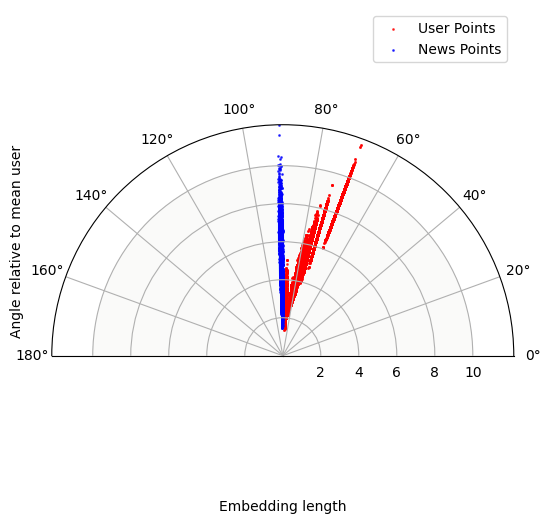

In [7]:
#N = 25 with disentanglement
process_embeddings_geometry(
    N=25,
    user_path= '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=50


/tmp/ipykernel_2122908/753296422.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings_tensor = torch.tensor(embeddings)  # Ensure embeddings are tensors
/tmp/ipykernel_2122908/753296422.py:38: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  return data[np.isfinite(data)]


Shannon Entropy for User Angles: 2.3195001717267436
Shannon Entropy for User Norms: 1.5705852654953698
Shannon Entropy for News Angles: 3.684839394649388
Shannon Entropy for News Norms: 0.17159837961471022


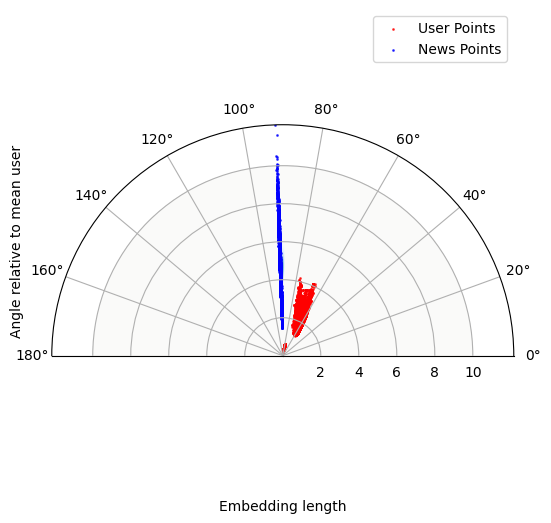

In [8]:
#N = 50 without disentanglement
process_embeddings_geometry(
    N=50,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing Geometry for N=50


/tmp/ipykernel_2122908/753296422.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings_tensor = torch.tensor(embeddings)  # Ensure embeddings are tensors
/tmp/ipykernel_2122908/753296422.py:38: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  return data[np.isfinite(data)]


Shannon Entropy for User Angles: 3.5046760332305795
Shannon Entropy for User Norms: 3.8732790297724997
Shannon Entropy for News Angles: 3.9977501418995813
Shannon Entropy for News Norms: 0.17159837961471022


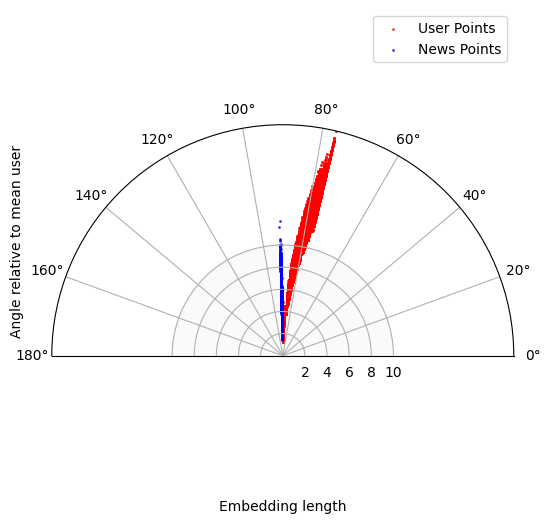

In [9]:
#N = 50 with disentanglement
process_embeddings_geometry(
    N=50,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl',
    candidate_path=candidate_path
)